# Enabling Validation for Robust Few-Shot Recognition

This notebook demonstrates how to perform **partial finetuning (PFT)** on CLIP for few-shot learning and evaluate the model on both ID and OOD datasets. Results are comparable to Table 2 in the paper.
1. model
    - CLIP ViT-B/16
2. few-shot setting
    - 16 shots
3. PFT setting
    - top-4 blocks
4. dataset
    - ImageNet-1k (as ID dataset)
    - ImageNet-V2 (as OOD dataset)
    - ImageNet-S (as OOD dataset)
    - ImageNet-A (as OOD dataset)
    - ImageNet-R (as OOD dataset)

In [1]:
import torch
import numpy as np
import random

# Set the random seed for reproducibility
training_seed = 1
data_seed = 1

random.seed(data_seed)
np.random.seed(training_seed)
torch.manual_seed(training_seed)
torch.cuda.manual_seed_all(training_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Partial finetuning

1. Load the CLIP model and prepare the dataset

In [ ]:
import clip.clip as clip
import datasets

# Load the CLIP ViT-B/16 model
clip_model, train_preprocess, test_preprocess= clip.load('ViT-B/16', jit=False)


# Prepare dataset and dataloader
root =  # Path to the ImageNet dataset
retrieved_root =  # Path to the retrieved dataset
num_shots = 16 # Number of shots for few-shot learning, options: 4, 8, 16
# ID train set
imagenet_train, text_name = datasets.build_imagenet_few_shot_dataset_demo('imagenet', 'train', data_seed, train_preprocess, root=root, num_shots=num_shots)
# ID test set
imagenet_test, _ = datasets.build_imagenet_dataset('imagenet', 'test', test_preprocess, root=root)
# OOD test sets
imagenet_a_test, _ = datasets.build_imagenet_dataset('imagenet_a', 'test', test_preprocess, root=root)
imagenet_r_test, _ = datasets.build_imagenet_dataset('imagenet_r', 'test', test_preprocess, root=root)
imagenet_sketch_test, _ = datasets.build_imagenet_dataset('imagenet_sketch', 'test', test_preprocess, root=root)
imagenetv2_test, _ = datasets.build_imagenet_dataset('imagenetv2', 'test', test_preprocess, root=root)
# validation set
valset_ID, _ = datasets.build_imagenet_few_shot_dataset_demo('imagenet', 'train', data_seed, test_preprocess, root=root, num_shots=num_shots)
valset_RT = datasets.build_validation_set_demo('retrieved', retrieved_root, data_seed, test_preprocess)

batch_size = 64
train_dataloader = torch.utils.data.DataLoader(
    dataset=imagenet_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    pin_memory=False)
val_dataloader_ID = torch.utils.data.DataLoader(
    dataset=valset_ID,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False)
val_dataloader_RT = torch.utils.data.DataLoader(
    dataset=valset_RT,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False)
val_dataloader = (val_dataloader_ID, val_dataloader_RT)

len(imagenet_train), len(valset_ID), len(valset_RT), len(imagenet_test), len(imagenet_a_test), len(imagenet_r_test), len(imagenet_sketch_test), len(imagenetv2_test)

Loading few-shot data from data_resource/imagenet/fewshot16_seed1.txt.
Loading few-shot data from data_resource/imagenet/fewshot16_seed1.txt.
Loading OOD validation data from data_resource/retrieved/val_seed1_retrieved.txt.


(16000, 16000, 45048, 50000, 7500, 30000, 50889, 10000)

2. Frozen the clip model except the top-X blocks of visual encoder.

In [3]:
def frozen(model, ft_topk_blks):
    for param in model.parameters():
        param.requires_grad = False

    if ft_topk_blks == -1:
        print('Finetune all blocks of the visual transformer.')
        for param in model.visual.parameters():
            param.requires_grad = True
    else:
        print(f'Finetune top-{ft_topk_blks} blocks of the visual transformer.')
        for blk in model.visual.transformer.resblocks[-ft_topk_blks:]:
            for param in blk.parameters():
                param.requires_grad = True

        for param in model.visual.ln_post.parameters():
            param.requires_grad = True
        model.visual.proj.requires_grad = True

# In our experiments, we adopt PFT on the top-4 blocks as the default setting.
ft_topk_blks = 4
frozen(clip_model, ft_topk_blks)

# double check the parameters
for name, param in clip_model.named_parameters():
    if param.requires_grad:
        print(name)

Finetune top-4 blocks of the visual transformer.
visual.proj
visual.transformer.resblocks.8.attn.in_proj_weight
visual.transformer.resblocks.8.attn.in_proj_bias
visual.transformer.resblocks.8.attn.out_proj.weight
visual.transformer.resblocks.8.attn.out_proj.bias
visual.transformer.resblocks.8.ln_1.weight
visual.transformer.resblocks.8.ln_1.bias
visual.transformer.resblocks.8.mlp.c_fc.weight
visual.transformer.resblocks.8.mlp.c_fc.bias
visual.transformer.resblocks.8.mlp.c_proj.weight
visual.transformer.resblocks.8.mlp.c_proj.bias
visual.transformer.resblocks.8.ln_2.weight
visual.transformer.resblocks.8.ln_2.bias
visual.transformer.resblocks.9.attn.in_proj_weight
visual.transformer.resblocks.9.attn.in_proj_bias
visual.transformer.resblocks.9.attn.out_proj.weight
visual.transformer.resblocks.9.attn.out_proj.bias
visual.transformer.resblocks.9.ln_1.weight
visual.transformer.resblocks.9.ln_1.bias
visual.transformer.resblocks.9.mlp.c_fc.weight
visual.transformer.resblocks.9.mlp.c_fc.bias
vis

3. Initialize the classifier with average text features of OpenAI 80 prompts.

In [4]:
import torch.nn as nn
class MyLinear(nn.Module):
    def __init__(self, input_dim=512, num_classes=1000, bias = False):
        super(MyLinear, self).__init__()

        self.linear = nn.Linear(input_dim, num_classes, bias=bias)
        self.num_classes = num_classes

    def forward(self, x):
        x = self.linear(x)

        return x

    def _init_weights(self, weights):
        # Initialize the weights of the linear layer with the given weights
        self.linear.weight = nn.Parameter(weights.clone())

In [5]:
import templates
def get_zeroshot_weights(text_name, template, logit_scale):
    zeroshot_weights = []
    template = getattr(templates, template)
    for classname in text_name:
        texts = []
        for t in template:
            texts.append(t(classname))
        texts = clip.tokenize(texts).cuda()
        embeddings = clip_model.encode_text(texts) #(80, dim)
        embeddings /= embeddings.norm(dim=-1, keepdim=True)
        
        embeddings = embeddings.mean(dim=0) #(dim)
        embeddings /= embeddings.norm()
    
        zeroshot_weights.append(embeddings)
    
    zeroshot_weights = torch.stack(zeroshot_weights, dim=0) #(1000, dim)
    zeroshot_weights *= logit_scale.exp()
    
    return zeroshot_weights

In [6]:
# Set classifier
num_classes = 1000  # Number of classes
num_features = 512  # Number of features

classifier = MyLinear(input_dim=num_features, num_classes=num_classes, bias=False)

# Initialize the classifier
logit_scale = clip_model.logit_scale
template = 'openai_imagenet_template' # OpenAI 80 prompts
with torch.no_grad():
    zeroshot_weights = get_zeroshot_weights(text_name, template, logit_scale)
classifier._init_weights(zeroshot_weights)

logit_scale, zeroshot_weights.shape

(Parameter containing:
 tensor(4.6052, device='cuda:0'),
 torch.Size([1000, 512]))

4. Define the optimizer and learning rate scheduler

In [7]:
from utils.scheduler import build_lr_scheduler

lr_backbone = 1e-6
lr_cls = 1e-3   # set the learning rate for the classifier
weight_decay = 0.1

# Define the optimizer
param_groups = [
            {"params": [p for name, p in clip_model.named_parameters() if p.requires_grad], "lr": lr_backbone},
            {"params": [p for p in classifier.parameters()], "lr": lr_cls},
        ]
optimizer = torch.optim.AdamW(param_groups, lr=lr_cls, weight_decay=weight_decay, betas=(0.9, 0.999))

# Define the learning rate scheduler
num_epochs = 50
total_iter = len(train_dataloader) * num_epochs
warmup_iter = 18
warmup_lr = 1e-8
scheduler = build_lr_scheduler(optimizer,
                               lr_scheduler="cosine",
                               warmup_iter=warmup_iter,
                               max_iter=total_iter,
                               warmup_type="linear",
                               warmup_lr=warmup_lr,
                               verbose=False)

5. Start training

In [8]:
def test(dataloader, model, classifier, test_label_map=None, device='cuda'):
    model.eval()
    classifier.eval()
    with torch.no_grad():
        targets_list = []
        preds_list = []
        for idx, (inputs, targets) in enumerate(dataloader):
            inputs = inputs.to(device)
            targets = targets.to(device)

            image_features = model.encode_image(inputs)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            outputs = classifier(image_features)
            outputs = outputs[:,test_label_map] # map the logits to the test dataset, primarily for ImageNet-A and ImageNet-R

            targets_list.append(targets.detach().cpu().numpy())
            preds_list.append(outputs.detach().cpu().numpy())

    targets_list = np.hstack(targets_list)
    preds_list = np.vstack(preds_list)
    preds_list = torch.tensor(preds_list)
    test_acc = (torch.softmax(preds_list, dim=1).argmax(1).numpy() == targets_list).mean()

    model.train()
    classifier.train()

    return test_acc*100

In [ ]:
import tqdm
import torchmetrics

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
CE_criterion = nn.CrossEntropyLoss()

best_val_acc = -1
loss, acc = [-1] * 2
val_acc = (-1, -1)
val_acc_list_ID = []
val_acc_list_RT = []
ckpt_path = 'demo_ckpt/PFT_top4/' # path to save checkpoints
num_iter = 0

clip_model.to(device)
classifier.to(device)
clip_model.train()
classifier.train()
print(f"Start few-shot finetuning ......")
for epoch in range(1, num_epochs + 1):

    train_acc = torchmetrics.Accuracy(num_classes=num_classes, task="multiclass", top_k=1)
    train_acc.to(device)

    pbar_iter = tqdm.tqdm(train_dataloader)
    for idx, (images, targets) in enumerate(pbar_iter):
        num_iter += 1
        pbar_iter.set_description(f"Epoch {epoch} / {num_epochs}, loss = {loss:.2f}, acc = {acc:.2f}, val_acc_ID = {val_acc[0]:.2f}, val_acc_RT = {val_acc[1]:.2f}, best_val_acc = {best_val_acc:.2f}")

        images = images.to(device)
        targets = targets.to(device)

        image_features = clip_model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        outputs = classifier(image_features)

        loss = CE_criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        acc = train_acc(outputs, targets) * 100

    # Validation
    val_acc_ID = test(dataloader=val_dataloader[0], model=clip_model, classifier=classifier, 
                      test_label_map=[i for i in range(1000)], device=device)
    val_acc_RT= test(dataloader=val_dataloader[1], model=clip_model, classifier=classifier, 
                     test_label_map=[i for i in range(1000)], device=device)
    
    # store both ID and RT val acc
    val_acc_list_ID.append(val_acc_ID/100)
    val_acc_list_RT.append(val_acc_RT/100)
    val_acc = (val_acc_ID, val_acc_RT)

    state = {}
    state['clip'] = clip_model.state_dict()
    state['head'] = classifier.state_dict()
    ckpt_name = f'model_bs{batch_size}_lr-cls{lr_cls}_lr-bkb{lr_backbone}_wd{weight_decay}_epoch_{epoch}_iter_{num_iter}.pth'
    torch.save(state, ckpt_path+ckpt_name) # Save the checkpoint

Start few-shot finetuning ......


Epoch 1 / 50, loss = 1.17, acc = 67.19, val_acc_ID = -1.00, val_acc_RT = -1.00, best_val_acc = -1.00: 100%|██████████| 250/250 [00:37<00:00,  6.61it/s]
Epoch 2 / 50, loss = 0.86, acc = 78.12, val_acc_ID = 74.34, val_acc_RT = 41.04, best_val_acc = -1.00: 100%|██████████| 250/250 [00:37<00:00,  6.61it/s]
Epoch 3 / 50, loss = 0.84, acc = 81.25, val_acc_ID = 76.99, val_acc_RT = 41.12, best_val_acc = -1.00: 100%|██████████| 250/250 [00:37<00:00,  6.60it/s]
Epoch 4 / 50, loss = 0.54, acc = 84.38, val_acc_ID = 79.07, val_acc_RT = 41.16, best_val_acc = -1.00: 100%|██████████| 250/250 [00:37<00:00,  6.60it/s]
Epoch 5 / 50, loss = 0.53, acc = 87.50, val_acc_ID = 81.06, val_acc_RT = 40.99, best_val_acc = -1.00: 100%|██████████| 250/250 [00:37<00:00,  6.60it/s]
Epoch 6 / 50, loss = 0.38, acc = 90.62, val_acc_ID = 82.84, val_acc_RT = 41.00, best_val_acc = -1.00: 100%|██████████| 250/250 [00:37<00:00,  6.59it/s]
Epoch 7 / 50, loss = 0.54, acc = 81.25, val_acc_ID = 84.41, val_acc_RT = 40.88, best_val

6. select checkpoint by $\text{gF1} = 2 \times \frac{\Delta_{ID} \times \Delta_{RT}}{\Delta_{ID} + \Delta_{RT}}$ (Eq. 2 in the paper)

In [10]:
EPS = 1e-9 # avoid dividing by zero

val_acc_list_ID = np.array(val_acc_list_ID)
val_acc_list_RT = np.array(val_acc_list_RT)
# calculate gF1 score
delta_ID = val_acc_list_ID - val_acc_list_ID.min()
delta_RT = val_acc_list_RT - val_acc_list_RT.min()
gF1_list = 2 * delta_ID * delta_RT / (delta_ID + delta_RT + EPS) 
# select the checkpoint with the highest gF1 score
best_gF1 = max(gF1_list)
best_epoch = np.argmax(gF1_list) + 1
best_iter = best_epoch * len(train_dataloader)

print(f'Best gF1 score: {round(best_gF1, 4)} at epoch {best_epoch}, iter {best_iter}')

Best gF1 score: 0.0314 at epoch 5, iter 1250


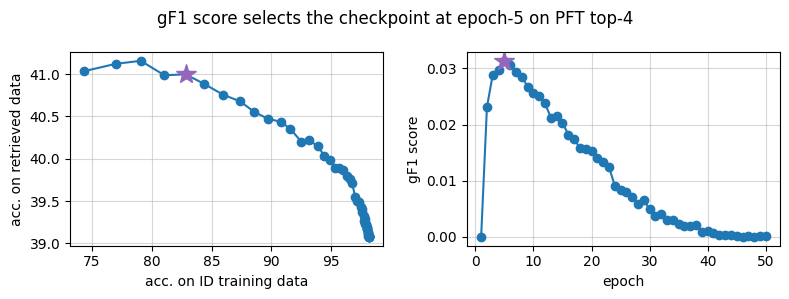

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.plot(val_acc_list_ID*100, val_acc_list_RT*100, marker='o')
plt.plot(val_acc_list_ID[best_epoch-1]*100, val_acc_list_RT[best_epoch-1]*100, marker='*', markersize=15, color="tab:purple")
plt.xlabel('acc. on ID training data')
plt.ylabel('acc. on retrieved data')
plt.grid(alpha=0.5)

plt.subplot(1,2,2)
plt.plot(np.arange(1,num_epochs+1), gF1_list, marker='o')
plt.plot(best_epoch, gF1_list[best_epoch-1], marker='*', markersize=15, color="tab:purple")
plt.xlabel('epoch')
plt.ylabel('gF1 score')
plt.grid(alpha=0.5)

plt.suptitle(f'gF1 score selects the checkpoint at epoch-{best_epoch} on PFT top-4')
plt.tight_layout()


7. Test the model on ID and OOD datasets

In [12]:
# load the checkpoint selected by gF1
best_model_path = ckpt_path + f'model_bs{batch_size}_lr-cls{lr_cls}_lr-bkb{lr_backbone}_wd{weight_decay}_epoch_{best_epoch}_iter_{best_iter}.pth'
checkpoint = torch.load(best_model_path) 
clip_model.load_state_dict(checkpoint['clip'])
classifier.load_state_dict(checkpoint['head'])

results_dict = {}
for test_dataset in [imagenet_test, imagenetv2_test, imagenet_sketch_test, imagenet_a_test, imagenet_r_test]:

    dataset_name = test_dataset.dataset_name
    test_dataloader = torch.utils.data.DataLoader(
        dataset=test_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=4)
    test_label_map = test_dataset.label_map
    test_acc = test(dataloader=test_dataloader, model=clip_model, classifier=classifier, 
                    test_label_map=test_label_map, device=device)
    results_dict[dataset_name] = {'test_acc': test_acc}

ood = []
for dataset_name in results_dict.keys():
    print(f"{dataset_name} Test acc = {results_dict[dataset_name]['test_acc']}")
    if dataset_name != 'ImageNet-1k':
        ood.append(results_dict[dataset_name]['test_acc'])
avg_ood = np.mean(ood)
print(f"Avg OOD Test acc = {avg_ood}")

ImageNet-1k Test acc = 73.354
ImageNet-v2 Test acc = 66.23
ImageNet-Sketch Test acc = 49.89290416396471
ImageNet-A Test acc = 52.04
ImageNet-R Test acc = 79.02333333333334
Avg OOD Test acc = 61.79655937432451
